<h1 align="center">Time Series Analysis of Brent Crude Oil Prices</h1>
<h3 align="center">Forecasting Monthly Prices Using ARIMA Models (1987–2026)</h3>

---

<p align="center">
<b>Course:</b> Time Series Analysis and Classification — TSAC 2025/2026 <br>
<b>Institution:</b> National School of Artificial Intelligence — ENSIA <br>
<b>Date:</b> March 2025
</p>

---

## Abstract

*To be completed after the full analysis is finished.*




<br>

## **1.Introduction**

Brent Crude Oil is a light, sweet crude extracted from the North Sea, and 
the world's main oil price benchmark, used to price around 70% of globally 
traded oil. Its price affects the cost of fuel, transport, food, and 
manufactured goods in virtually every country. For Algeria specifically, 
oil exports make up the majority of government revenue, meaning Brent price 
movements directly impact the national budget and economy. Being able to model and forecast this price is therefore of direct practical relevance for economic planning and policy decisions.

The dataset used in this project contains 465 monthly observations of the 
Brent Crude Oil spot price in US dollars per barrel, downloaded from the 
Federal Reserve Economic Data platform (FRED). It covers June 1987 to 
February 2026 , a period that includes major global events such as the 1990 
Gulf War, the 2008 financial crisis, the 2020 COVID-19 crash, and the 2022 
Ukraine war, all of which produced sharp movements in the price series.

This study applies statistical ARIMA models to characterize the behavior 
of the series and generate future price forecasts. The analysis covers data 
preparation, stationarity testing, model identification, fitting, diagnostic 
checking, and forecast evaluation against withheld observations.

**Dataset:** [Brent Crude Oil Monthly Prices — FRED via Google Drive](
https://drive.google.com/file/d/1ZzDUur0XT4rl1_QCZAT2kvuy8yUH2Ou2/view?usp=sharing)
<br>

## **2.Model Specification**

This section describes the full process used to identify candidate models 
for the Brent Crude Oil price series. It covers data preparation, visual 
inspection, variance stabilization, stationarity testing, and ACF/PACF 
analysis. Each step builds on the previous one and leads to a justified 
selection of candidate ARIMA models.

<h3 style="color:#aeb8c2; font-weight:700;">2.1 Data Preparation</h3>
Before any analysis begins, the dataset is loaded, inspected, and 
converted into a proper time series object. This step verifies that 
the data is complete, correctly formatted, and ready for analysis.

In [24]:
# Load libraries 
library(tseries)    # ADF stationarity test
library(forecast)   # ARIMA fitting and diagnostics
library(MASS)       # Box-Cox transformation
library(ggplot2)    # Plotting
library(readr)      # Data loading
library(dplyr)      # Data manipulation



Attaching package: 'dplyr'


The following object is masked from 'package:MASS':

    select


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [14]:
# Load dataset (local + Google Colab)
data_file  <- "DCOILBRENTEU.csv"
drive_link <- "https://drive.google.com/file/d/1ZzDUur0XT4rl1_QCZAT2kvuy8yUH2Ou2/view?usp=sharing"

# Convert share link to direct download link
file_id <- sub(".*?/d/([A-Za-z0-9_-]+).*", "\\1", drive_link)
download_url <- paste0("https://drive.google.com/uc?export=download&id=", file_id)

# Download only if file is not already in the folder
if (!file.exists(data_file)) {
  download.file(download_url, destfile = data_file, mode = "wb")
}

oil_raw <- read.csv(data_file)

# Convert date column
oil_raw$observation_date <- as.Date(oil_raw$observation_date)

# First look at the data
head(oil_raw, 5)
tail(oil_raw, 5)

# Check structure and dimensions
cat("Date column class :", class(oil_raw$observation_date), "\n")
cat("Rows             :", nrow(oil_raw), "\n")
cat("Columns          :", ncol(oil_raw), "\n")
cat("Names            :", names(oil_raw), "\n")

,observation_date,DCOILBRENTEU
,<date>,<dbl>
1,1987-06-01,18.86
2,1987-07-01,19.86
3,1987-08-01,18.98
4,1987-09-01,18.31
5,1987-10-01,18.76


,observation_date,DCOILBRENTEU
,<date>,<dbl>
461,2025-10-01,64.54
462,2025-11-01,63.80
463,2025-12-01,62.54
464,2026-01-01,66.60
465,2026-02-01,70.89


Date column class : Date 
Rows             : 465 
Columns          : 2 
Names            : observation_date DCOILBRENTEU 


In [15]:
# Check for missing values in price column
cat("Missing prices :", sum(is.na(oil_raw$DCOILBRENTEU)), "\n")

# Check if all months are present (no gaps)
# Generate the full expected sequence of monthly dates
expected_dates <- seq(
  from = as.Date("1987-06-01"),
  to   = as.Date("2026-02-01"),
  by   = "month"
)

# Find any missing months
missing_months <- expected_dates[!expected_dates %in% oil_raw$observation_date]

if (length(missing_months) == 0) {
  cat("No missing months :",length(expected_dates),
      "months present.\n")
} else {
  cat("Missing months found:\n")
  print(missing_months)
}

Missing prices : 0 


No missing months : 465 months present.


In [16]:
# Create time series object 
# Monthly frequency = 12, starting June 1987
oil_ts <- ts(oil_raw$DCOILBRENTEU,
             start     = c(1987, 6),
             frequency = 12)
             
# Sanity check 
cat("════════════════════════════════════\n")
cat("Time Series Object - Sanity Check \n")
cat("════════════════════════════════════\n")
cat("Observations  :", length(oil_ts),       "\n")
cat("Start         :", start(oil_ts),         "\n")
cat("End           :", end(oil_ts),           "\n")
cat("Frequency     :", frequency(oil_ts),     "\n")
cat("Missing values:", sum(is.na(oil_ts)),    "\n")
cat("Min price     :", round(min(oil_ts), 2), "\n")
cat("Max price     :", round(max(oil_ts), 2), "\n")
cat("Mean price    :", round(mean(oil_ts), 2),"\n")


════════════════════════════════════
Time Series Object - Sanity Check 
════════════════════════════════════
Observations  : 465 
Start         : 1987 6 
End           : 2026 2 
Frequency     : 12 
Missing values: 0 
Min price     : 9.82 
Max price     : 132.72 
Mean price    : 50.97 


<span style="color: #1b8a3a;"><strong>Interpretation of the data loading and preparation process:</strong></span>
The dataset was successfully loaded and contains **465 observations** 
across **2 columns** , the observation date and the monthly Brent Crude 
Oil price in USD per barrel. The `observation_date` column was converted 
from character format to a proper Date type to ensure correct time 
ordering.

The data quality checks confirm that the series is complete and ready 
for analysis:

- **No missing prices** : all 465 price values are present
- **No missing months** : every month from June 1987 to February 2026 
  is accounted for with no calendar gaps
- **Frequency** : monthly (12 observations per year)
- **Price range** : minimum of **$9.82** per barrel (recorded during 
  the 1998 Asian financial crisis) and a maximum of **$132.72** 
  (recorded during the 2008 commodity boom)
- **Mean price** : **$50.97** per barrel over the full sample period

The time series object was created with `start = c(1987, 6)` and 
`frequency = 12`, correctly representing monthly observations beginning 
June 1987.
<br>
<br>



<h3 style="color:#aeb8c2; font-weight:700;">2.2 Visual Inspection of the Raw Series</h3>

The first step in any time series analysis is to plot the raw data. 
This allows us to visually assess the key properties of the series — 
whether it has a trend, whether its variance changes over time, and 
whether it appears stationary or not. These observations directly 
guide the transformations and modeling choices that follow.

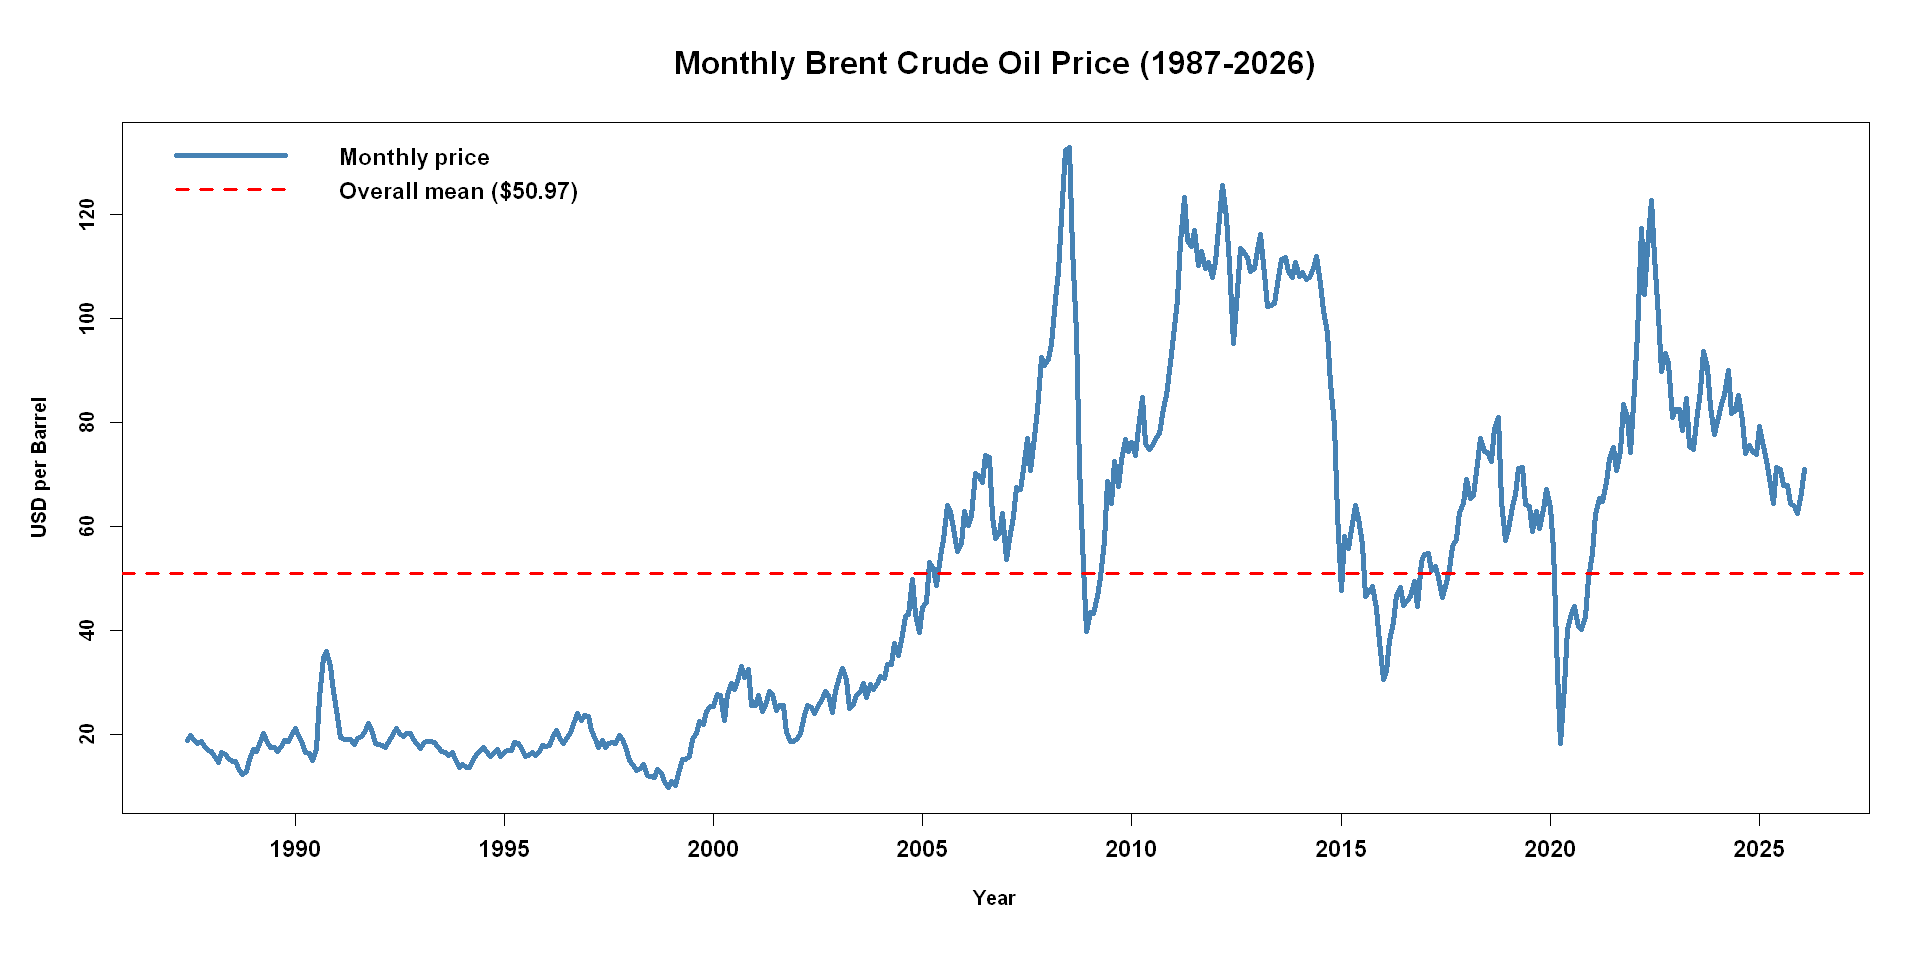

In [41]:
options(repr.plot.width = 16, repr.plot.height = 8)
par(
  bg = "white",
  mar = c(6, 5, 5, 2) + 0.1,
  font.lab = 2,
  font.axis = 2
 )

year_ticks <- seq(1990, 2025, by = 5)
mean_price <- mean(oil_ts)

plot(
  oil_ts,
  main = "Monthly Brent Crude Oil Price (1987-2026)",
  xlab = "Year",
  ylab = "USD per Barrel",
  col = "steelblue",
  lwd = 4,
  xaxt = "n",
  cex.main = 1.6,
  cex.lab = 1.35,
  font.main = 2
)

axis(1, at = year_ticks, labels = year_ticks, cex.axis = 1.2, font = 2)
abline(h = mean_price, col = "red", lty = 2, lwd = 3)

legend(
  "topleft",
  legend = c("Monthly price", "Overall mean ($50.97)"),
  col = c("steelblue", "red"),
  lty = c(1, 2),
  lwd = c(4, 3),
  cex = 1.15,
  text.font = 2,
  bty = "n"
)

<span style="color: #1b8a3a;"><strong>Interpretation of the raw series plot:</strong></span>
The plot shows the monthly Brent Crude Oil price series over the 
full sample period.

**Trend:** The series exhibits both upward and downward trends across 
the sample period, driven by major economic events such as the 2008 
financial crisis and the 2020 COVID-19 crash, meaning the mean is 
not constant over time.

**Variance:** Price fluctuations are noticeably larger in the second 
half of the sample than in the first, suggesting that the variance 
grows with the price level.

**Autocorrelation:** Consecutive monthly prices move together 
smoothly, indicating strong positive autocorrelation and a high 
degree of persistence in the series.

Overall, the series does not appear to be stationary. Two issues must be addressed before modeling: the non-constant variance and the non-constant mean
<br>
<br>



<h3 style="color:#aeb8c2; font-weight:700;">2.3  Train/Test Split</h3>
Before any statistical analysis begins, the dataset is split into a 
training set and a test set. All steps in the model specification 
and fitting sections are carried out exclusively on the training set. 
The test set is withheld and only used in the forecasting section to 
evaluate the model's predictive performance on unseen data.

A 90/10 split is applied , the last 46 observations covering 
May 2022 to February 2026 are reserved as the test set, while the 
remaining 419 observations from June 1987 to April 2022 form the 
training set.

In [44]:
# ── Train/Test Split (90/10) ──────────────────────────────────
# Calculate split point
n_total <- length(oil_ts)
n_test  <- round(n_total * 0.10)
n_train <- n_total - n_test

cat("Total observations   :", n_total, "\n")
cat("Training observations:", n_train, "\n")
cat("Test observations    :", n_test,  "\n")

# ── Create train and test sets using index ────────────────────
train_ts <- head(oil_ts, n_train)
test_ts  <- tail(oil_ts, n_test)

# ── Confirm periods ───────────────────────────────────────────
cat("Training period      :", start(train_ts),
                        "to", end(train_ts),  "\n")
cat("Test period          :", start(test_ts),
                        "to", end(test_ts),   "\n")

Total observations   : 465 
Training observations: 419 
Test observations    : 46 
Training period      : 1987 6 to 2022 4 
Test period          : 2022 5 to 2026 2 



<h3 style="color:#aeb8c2; font-weight:700;">2.4 Variance Stabilization</h3>

The visual inspection of the raw series suggested that the **variance 
is not constant** , price fluctuations grow larger as the price level 
increases. To formally verify this and determine the appropriate 
transformation, a Box-Cox analysis is applied to the training set.

The Box-Cox family of transformations is defined as:

$$T(Y_t) = \begin{cases} \frac{Y_t^\lambda - 1}{\lambda} & \lambda \neq 0 \\ \ln(Y_t) & \lambda = 0 \end{cases}$$

The optimal λ is selected by maximizing the log-likelihood over a 
range of candidate values. A value of λ = 1 indicates that no 
transformation is needed. A value of λ = 0 corresponds to a log 
transformation, which is the most common choice for financial and 
commodity price series. If the optimal λ is significantly different 
from 1, a transformation is required to stabilize the variance 
before modeling.

In [47]:
#  Box-Cox lambda search on training set 
lambda_result <- BoxCox.lambda(train_ts,
                               method = "loglik",
                               lower  = -2,
                               upper  =  2)

cat("Optimal lambda:", round(lambda_result, 4), "\n")

# Interpretation 
if (abs(lambda_result - 1) < 0.1) {
  cat("Lambda is close to 1 — no transformation needed.\n")
} else if (abs(lambda_result) < 0.1) {
  cat("Lambda is close to 0 — log transformation recommended.\n")
} else {
  cat("Lambda =", round(lambda_result, 4),
      ", Box-Cox transformation recommended.\n")
}

Optimal lambda: -0.3 
Lambda = -0.3 , Box-Cox transformation recommended.


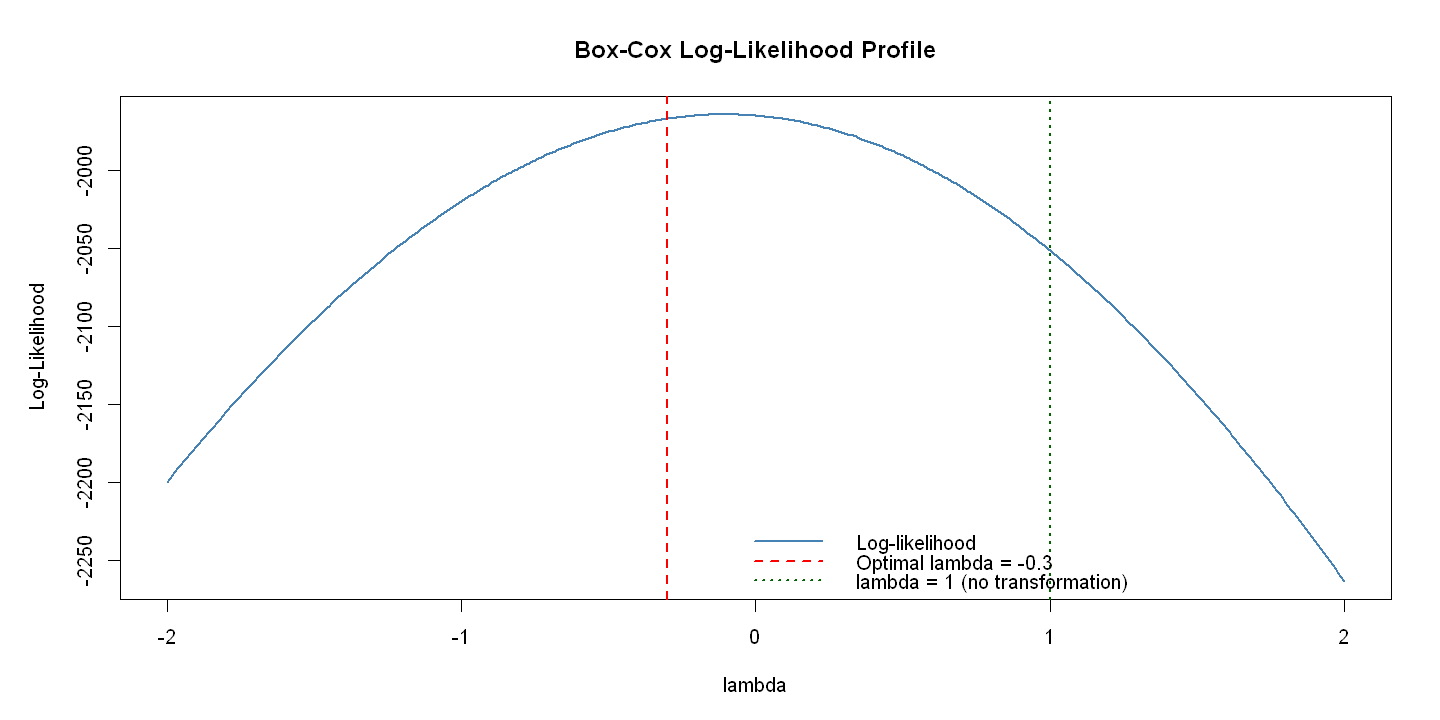

In [49]:
# Plot Box-Cox log-likelihood profile
options(repr.plot.width = 12, repr.plot.height = 6)

lambda_seq <- seq(-2, 2, by = 0.01)
ll_vals    <- sapply(lambda_seq, function(l) {
  tryCatch(
    sum(dnorm(
      BoxCox(train_ts, lambda = l),
      mean = mean(BoxCox(train_ts, lambda = l)),
      sd   = sd(BoxCox(train_ts, lambda = l)),
      log  = TRUE
    ) + (l - 1) * log(train_ts)),
    error = function(e) NA
  )
})

par(bg  = "white",
    mar = c(5, 5, 4, 2))

plot(lambda_seq, ll_vals,
     type = "l",
     col  = "steelblue",
     lwd  = 2,
     main = "Box-Cox Log-Likelihood Profile",
     xlab = "lambda",
     ylab = "Log-Likelihood")

abline(v   = lambda_result,
       col = "red",
       lty = 2,
       lwd = 2)

abline(v   = 1,
       col = "darkgreen",
       lty = 3,
       lwd = 2)

legend("bottomright",
       legend = c("Log-likelihood",
                  paste0("Optimal lambda = ", round(lambda_result, 4)),
                  "lambda = 1 (no transformation)"),
       col    = c("steelblue", "red", "darkgreen"),
       lty    = c(1, 2, 3),
       lwd    = c(2, 2, 2),
       bty    = "n")

<span style="color: #1b8a3a;"><strong>Interpretation : </strong></span>
The Box-Cox analysis returns an optimal λ = -0.3, which is 
significantly different from 1. This confirms that the variance 
of the training series is not constant and a transformation is 
required before modeling.

Since λ = -0.3 is close to 0, it suggests that a log-like 
transformation is appropriate. The log-likelihood profile plot 
shows a clear peak at λ = -0.3, well away from λ = 1 (green 
dotted line), which would correspond to no transformation. 
The Box-Cox transformation with λ = -0.3 is therefore applied 
to the training set to stabilize the variance.

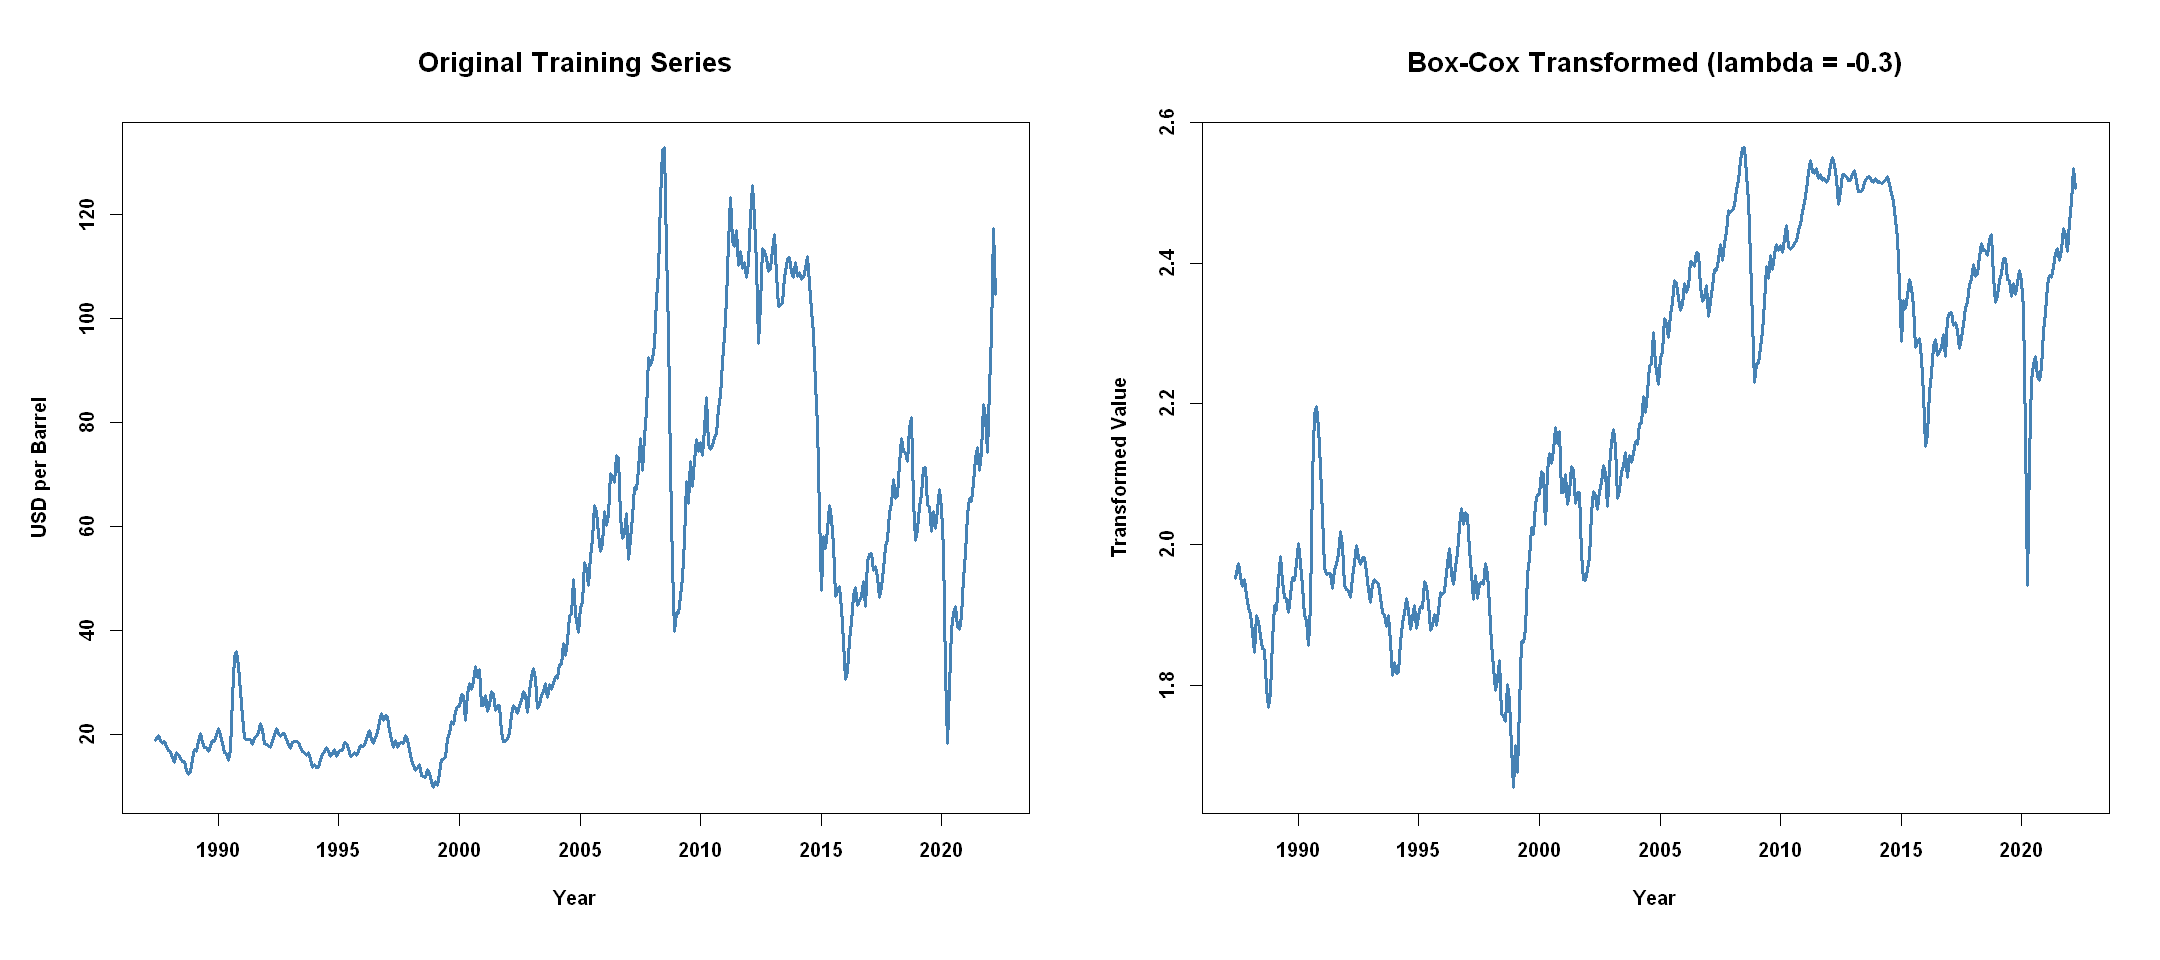

In [48]:
# Apply Box-Cox transformation to training set
train_bc <- BoxCox(train_ts, lambda = lambda_result)

# Side-by-side comparison with the same visual style as the raw-series plot
options(repr.plot.width = 18, repr.plot.height = 8)

par(mfrow = c(1, 2),
    bg = "white",
    mar = c(6, 5, 5, 2) + 0.1,
    font.lab = 2,
    font.axis = 2)

# Original series
plot(train_ts,
     main = "Original Training Series",
     ylab = "USD per Barrel",
     xlab = "Year",
     col  = "steelblue",
     lwd  = 3,
     cex.main = 1.35,
     cex.lab = 1.2,
     font.main = 2)

# Transformed series (ASCII text to avoid Windows encoding warning)
plot(train_bc,
     main = paste0("Box-Cox Transformed (lambda = ",
                   round(lambda_result, 4), ")"),
     ylab = "Transformed Value",
     xlab = "Year",
     col  = "steelblue",
     lwd  = 3,
     cex.main = 1.35,
     cex.lab = 1.2,
     font.main = 2)

par(mfrow = c(1, 1))

<span style="color: #1b8a3a;"><strong>Interpretation : </strong></span>
Comparing the two plots, the effect of the Box-Cox transformation with λ = −0.3 is evident. In the original series, the amplitude of fluctuations increases with the level of the series: the swings during the 2005–2015 period are considerably larger than those observed between 1987 and 2000. After applying the transformation, the fluctuations appear more uniform over the entire time span, suggesting that the variance has been stabilized.

However, the transformed series still displays a clear upward trend, indicating that the mean of the process may not be constant over time. To formally assess stationarity, the Augmented Dickey–Fuller test is applied to the transformed series.

In [51]:
# ADF test on Box-Cox transformed training series 
adf_bc <- adf.test(train_bc)
print(adf_bc)


	Augmented Dickey-Fuller Test

data:  train_bc
Dickey-Fuller = -2.4529, Lag order = 7, p-value = 0.3861
alternative hypothesis: stationary



**ADF Test Result**
The Augmented Dickey-Fuller test on the Box-Cox transformed series gives a test statistic of -2.4529 and a p-value of 0.3861.

Because this p-value is much larger than 0.05, we fail to 
reject the null hypothesis of a unit root. This confirms that the 
transformed series is not stationary , the mean is still not 
constant over time and a trend remains present.

Differencing is therefore required to achieve stationarity.
Therefore, differencing is needed before fitting ARIMA models.
<br>
<br>


<h3 style="color:#aeb8c2; font-weight:700;">2.5 Stationarity and Differencing</h3>
The ADF test confirmed that the Box-Cox transformed series is not 
stationary. The trend must be removed before any ARIMA model can 
be applied.

Although several techniques exist for removing trend , such as 
regression detrending and moving average smoothing , differencing 
is the most commonly used method in ARIMA modeling because it 
directly produces the integrated component of the model and does 
not require assuming a specific functional form for the trend.

First-order differencing is applied to the transformed training 
series. The resulting series is then plotted and tested formally 
using the ADF test to confirm that stationarity has been achieved.

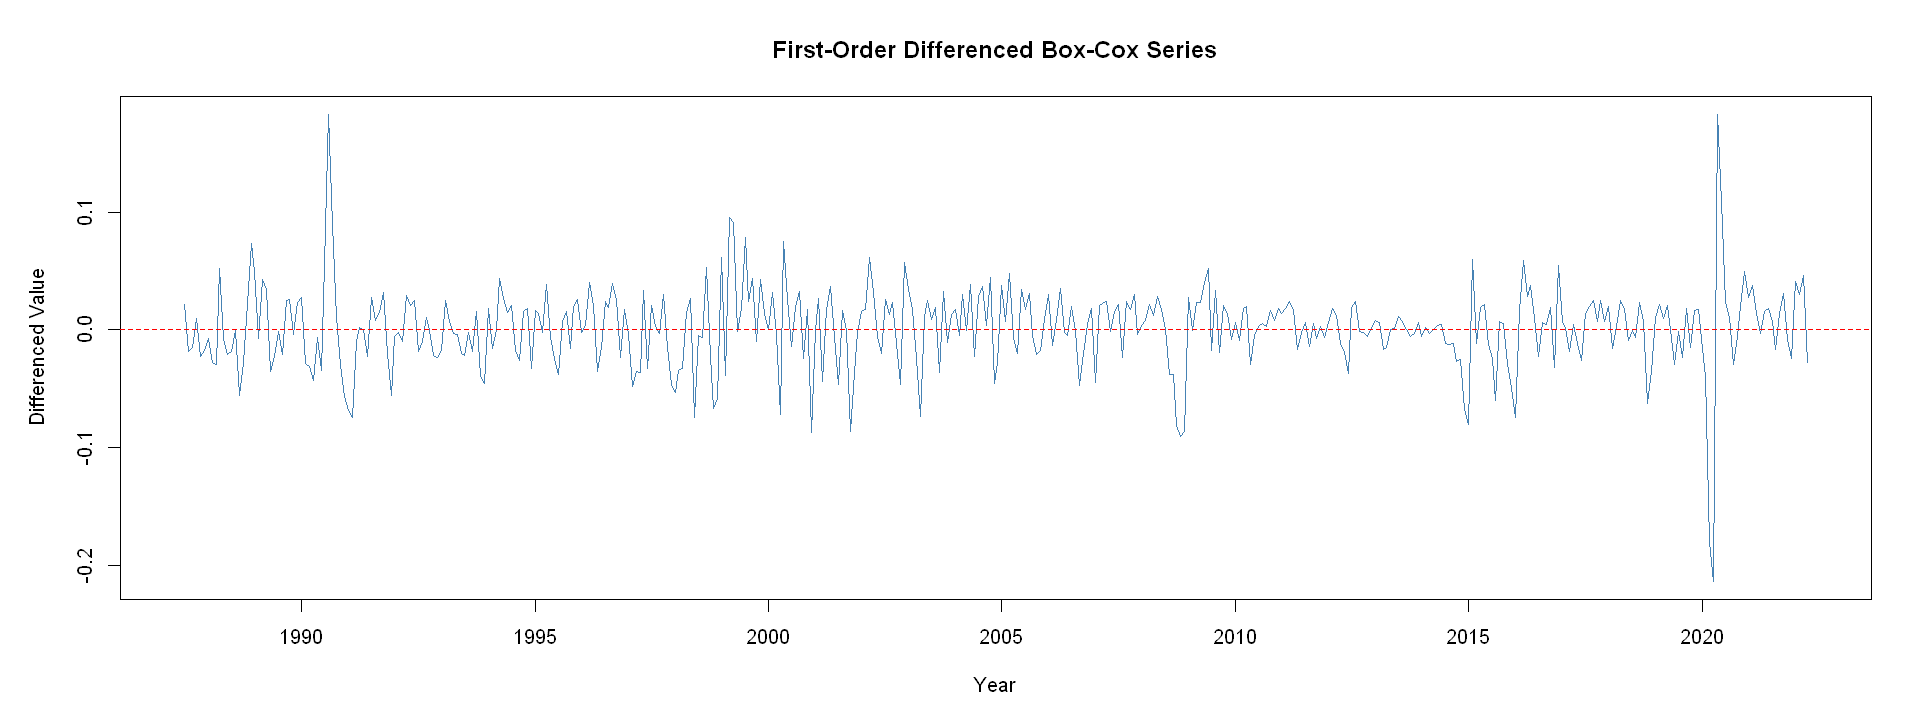

In [54]:
# First order differencing on transformed series 
train_diff <- diff(train_bc, lag = 1)

# Plot differenced series 
options(repr.plot.width = 16, repr.plot.height = 6)

par(bg  = "white",
    mar = c(5, 5, 4, 2))

plot(train_diff,
     main = "First-Order Differenced Box-Cox Series",
     ylab = "Differenced Value",
     xlab = "Year",
     col  = "steelblue",
     lwd  = 1.5)

abline(h   = 0,
       col = "red",
       lty = 2,
       lwd = 1.5)

In [58]:
# ADF test on differenced transformed series
adf_diff <- adf.test(train_diff)
print(adf_diff)

Warning message in adf.test(train_diff):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  train_diff
Dickey-Fuller = -8.0772, Lag order = 7, p-value = 0.01
alternative hypothesis: stationary



<span style="color: #1b8a3a;"><strong>Interpretation :  </strong></span>The plot of the first-order differenced Box-Cox series shows that 
the series now fluctuates around zero with no visible trend. The 
mean appears constant across the full sample period, which is a 
first visual indication that stationarity has been achieved. Two 
isolated spikes are visible around 1991 and 2020  corresponding 
to the Gulf War and the COVID-19 demand collapse respectively. These 
are extreme but isolated events and do not reflect a systematic 
pattern in the series.

<span style="color: #1b8a3a;"><strong>Augmented Dickey-Fuller (ADF) Test Results</strong></span>
- The ADF test returns a test statistic of **-8.0772** and a 
**p-value = 0.01**. The warning message indicates that the real 
p-value is even smaller than 0.01.
- Since the **p-value < 0.05**, we **reject H₀** (unit root), 
confirming that the differenced series is **stationary**.
- One order of differencing was sufficient to achieve stationarity, 
meaning the integrated order of the model is **d = 1**.
- Since differencing has successfully made the series stationary, 
an  <span style="color: #c62828;"><strong>ARIMA(p, 1, q)</strong></span> model is appropriate.
- The orders **p** (AR component) and **q** (MA component) will 
be determined in the following subsection using the ACF and PACF 
plots.

<br>
<br>



<h3 style="color:#aeb8c2; font-weight:700;">2.6 ACF and PACF Analysis</h3>

Now that the series is stationary, the Autocorrelation Function 
(ACF) and Partial Autocorrelation Function (PACF) are examined 
to identify the orders p and q of the ARIMA(p, 1, q) model.

The ACF measures the correlation between the series and its lagged 
values. The PACF measures the same correlation but after removing 
the effect of intermediate lags. Together they provide the 
following guidance:

- If the **ACF cuts off** after lag q and the **PACF tails off** 
→ suggests an **MA(q)** process
- If the **PACF cuts off** after lag p and the **ACF tails off** 
→ suggests an **AR(p)** process
- If **both tail off** → suggests an **ARMA(p, q)** process

Any spike that crosses the blue dashed confidence bands is 
considered statistically significant.

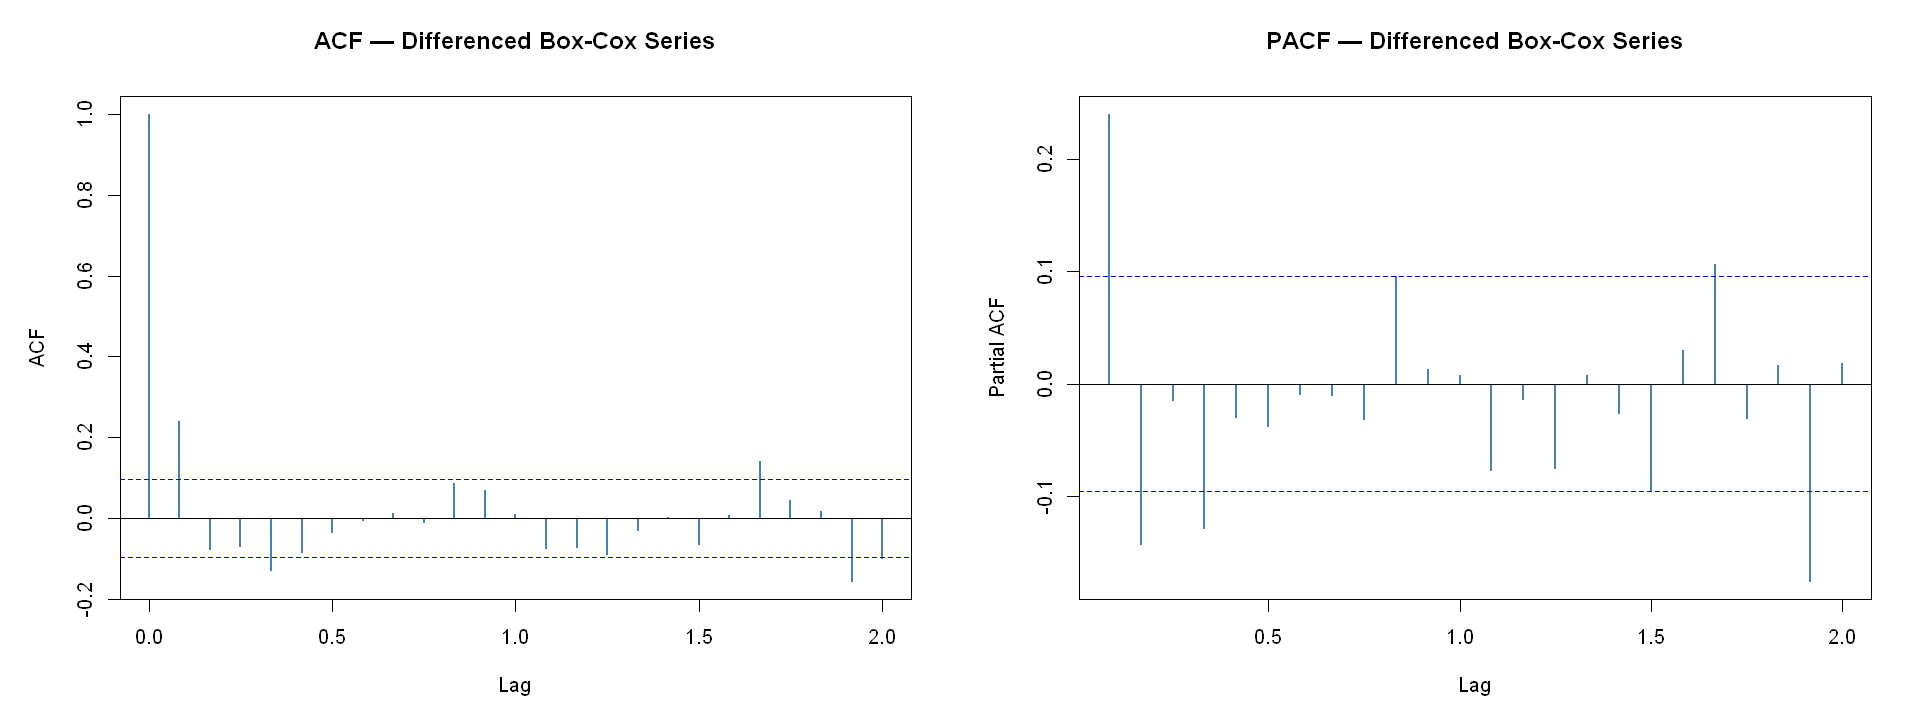

In [ ]:
# ACF and PACF of differenced Box-Cox series 
options(repr.plot.width = 16, repr.plot.height = 6)

par(mfrow = c(1, 2),
    bg    = "white",
    mar   = c(5, 5, 4, 2))

acf(train_diff,
    lag.max  = 24,
    main     = "ACF — Differenced Box-Cox Series",
    col      = "steelblue",
    lwd      = 2)

pacf(train_diff,
     lag.max = 24,
     main    = "PACF — Differenced Box-Cox Series",
     col     = "steelblue",
     lwd     = 2)

par(mfrow = c(1, 1))

<span style="color: #1b8a3a;"><strong>Interpretation</strong></span>

**ACF:** One significant spike is observed at lag 1, after which 
the values fall within the confidence bands. A few isolated spikes 
appear at higher lags but follow no regular pattern and are 
considered negligible. The overall pattern suggests a cut-off 
after lag 1 , characteristic of an MA(1) process.

**PACF:** Significant spikes are observed at lags 1 and 2, after 
which the values tail off gradually toward zero. This tailing-off 
pattern is characteristic of an Autoregressive process.

Based on the ACF and PACF patterns, the following candidate models 
are identified for the ARIMA(p, 1, q) framework:

| Model | AR order (p) | d | MA order (q) | Justification |
|---|---|---|---|---|
| ARIMA(0,1,1) | 0 | 1 | 1 | ACF cuts off at lag 1, PACF tails off |
| ARIMA(1,1,1) | 1 | 1 | 1 | Both ACF and PACF show lag 1 significance |
| ARIMA(2,1,1) | 2 | 1 | 1 | PACF significant at lags 1 and 2, ACF cuts at lag 1 |
| ARIMA(1,1,0) | 1 | 1 | 0 | PACF cuts off at lag 1 as an alternative |
| ARIMA(2,1,0) | 2 | 1 | 0 | PACF significant at lags 1 and 2 |

These five candidate models will be fitted and compared in the 
next section using the Akaike Information Criterion (AIC) and 
the Bayesian Information Criterion (BIC) to identify the best 
fitting model.